In [1]:
target_cols = 'K_Nu'

output_file=f'{target_cols} determ.csv'
columns = ['K_Nu', 'K_E', 'K_Rho', 'K_incl', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z']
p1, p2, p3 = 0.0, 10.1, 0.5

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.optimizers import Adam

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
import pandas as pd
df = pd.read_csv(output_file)
df

,K_Nu,K_E,K_Rho,K_incl_top_position_y,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z
0,0.8000,1,1,1,0.1,10.000000,5.331371e-13,5.331386e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446
1,0.8000,1,1,1,0.2,5.000000,5.334869e-13,5.331507e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446
2,0.8000,1,1,1,0.3,3.333333,5.366543e-13,5.363065e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446
3,0.8000,1,1,1,0.4,2.500000,5.329471e-13,5.332102e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446
4,0.8000,1,1,1,0.5,2.000000,5.331205e-13,5.332521e-13,0.25,5.000000e+10,2700,4536.092116,2777.777778,2502.294446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100095,0.8036,1,1,1,9.6,0.104167,5.367186e-13,5.358007e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446
100096,0.8036,1,1,1,9.7,0.103093,5.369076e-13,5.359525e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446
100097,0.8036,1,1,1,9.8,0.102041,5.370946e-13,5.361025e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446
100098,0.8036,1,1,1,9.9,0.101010,5.372790e-13,5.362506e-13,0.25,5.000000e+10,2700,4538.653819,2776.736697,2502.294446


In [5]:
delete_values = np.arange(p1, p2, p3).round(1).tolist()
df = df[df['F'].round(1).isin(delete_values)]

In [6]:
df['A2/A2_s'] = df['A2'] / df['А2_surface']
y = df[target_cols]
X = df[['A2/A2_s', 'F']]
X[:5]

C:\Users\1\AppData\Local\Temp\ipykernel_26696\3331272413.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['A2/A2_s'] = df['A2'] / df['А2_surface']


,A2/A2_s,F
4,0.999753,0.5
9,1.002399,1.0
14,1.011061,1.5
19,1.016626,2.0
24,1.002829,2.5


In [7]:
scaler_X = StandardScaler()

X_scaled = scaler_X.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [9]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(2,), name='hidden_layer_1'),
    Dropout(0.2),  # Добавляем Dropout для регуляризации
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dropout(0.2),
    Dense(1, name='output_layer')
])

C:\Users\1\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Ранняя остановка для предотвращения переобучения
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Обучение модели
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0548 - mae: 0.1673 - val_loss: 0.0069 - val_mae: 0.0676
Epoch 2/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0168 - mae: 0.1026 - val_loss: 0.0056 - val_mae: 0.0557
Epoch 3/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0137 - mae: 0.0923 - val_loss: 0.0050 - val_mae: 0.0505
Epoch 4/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0118 - mae: 0.0861 - val_loss: 0.0047 - val_mae: 0.0476
Epoch 5/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0101 - mae: 0.0793 - val_loss: 0.0044 - val_mae: 0.0477
Epoch 6/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0089 - mae: 0.0737 - val_loss: 0.0039 - val_mae: 0.0430
Epoch 7/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0079 - mae: 0.0691 - val_loss: 0.0037 - val_mae: 0.0411
Epoch 8/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0069 - mae: 0.0640 - val_loss: 0.0038 - val_mae: 0.0438
Epoch 9/100
401/401 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/

In [13]:
y_pred= np.array(model.predict(X_test)).flatten()
y_test = np.array(y_test)
y_test, y_pred

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


(array([1.184 , 1.0088, 1.1784, ..., 1.166 , 1.1564, 1.1908]),
 array([1.1462842, 1.0106803, 1.0809788, ..., 1.1566314, 1.1390663,
        1.156775 ], dtype=float32))

In [14]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
relative_errors = np.abs((y_test - y_pred) / y_test) * 100
mean_relative_error = np.mean(relative_errors)
std_relative_error = np.std(relative_errors)

In [15]:

print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ МОДЕЛИ")
print("="*50)
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Absolute Per Error (MAPE): {mape:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.6f}")


РЕЗУЛЬТАТЫ МОДЕЛИ
Mean Squared Error (MSE): 0.000589
Mean Absolute Error (MAE): 0.014087
Mean Absolute Per Error (MAPE): 0.014624
Root Mean Squared Error (RMSE): 0.024260
R² Score: 0.955822


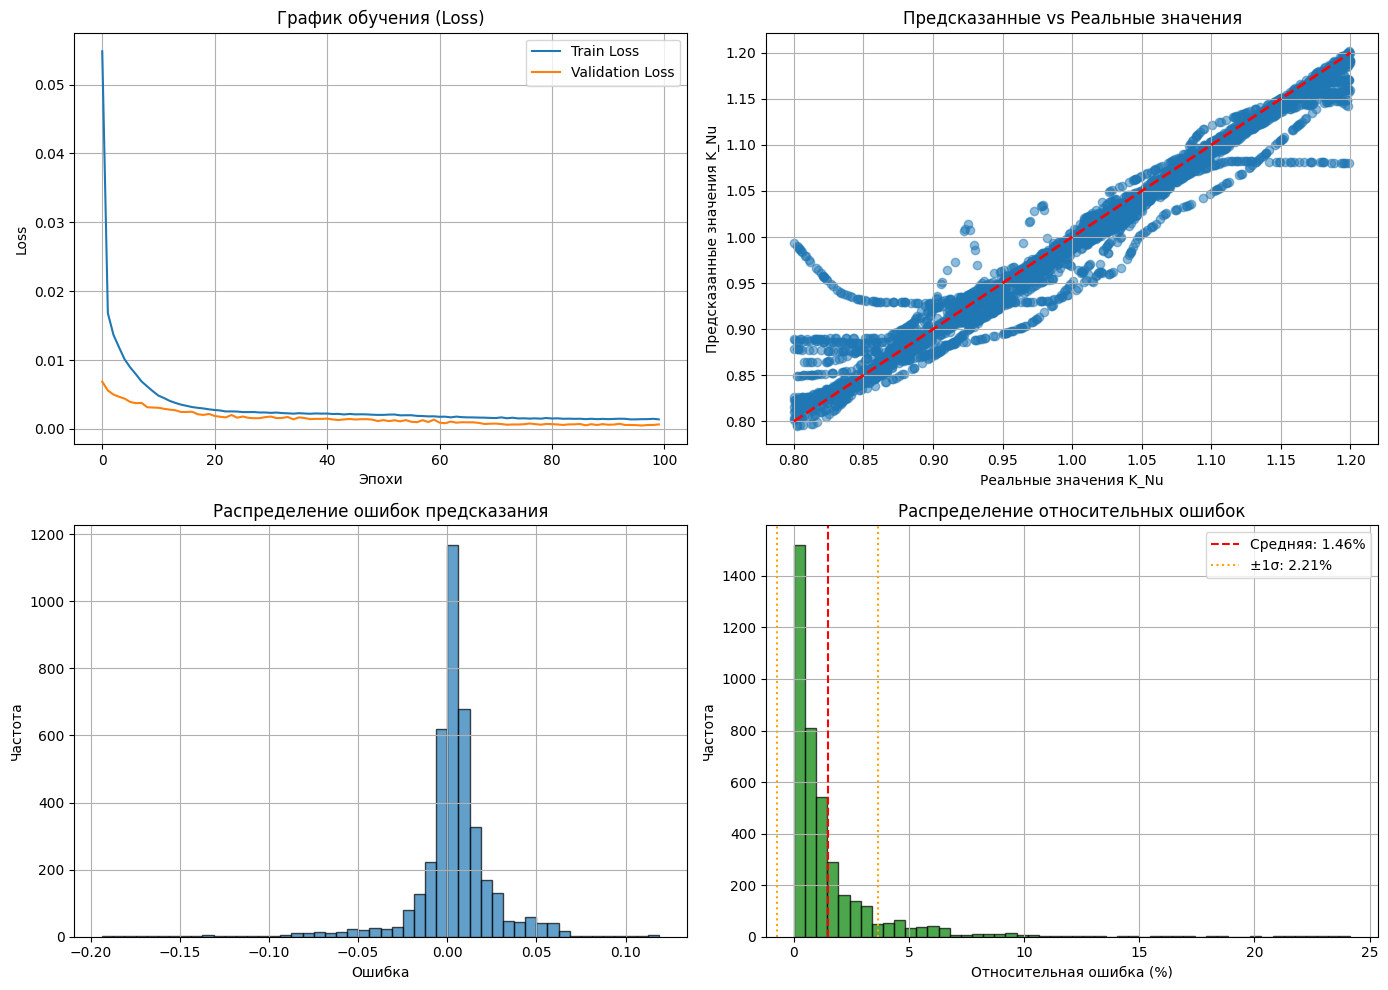


ДЕТАЛЬНАЯ СТАТИСТИКА
Минимальная относительная ошибка: 0.00%
Максимальная относительная ошибка: 24.17%
Медианная относительная ошибка: 0.75%
25-й перцентиль: 0.30%
75-й перцентиль: 1.64%

ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)
 Реальный K_Nu  Предсказанный K_Nu  Абсолютная ошибка  Относительная ошибка (%)
        1.1840            1.146284           0.037716                  3.185454
        1.0088            1.010680           0.001880                  0.186392
        1.1784            1.080979           0.097421                  8.267248
        0.9060            0.882388           0.023612                  2.606201
        0.8888            0.879474           0.009326                  1.049268
        0.8592            0.929936           0.070736                  8.232781
        1.0384            1.038170           0.000230                  0.022128
        0.8884            0.914071           0.025671                  2.889539
        0.8764            0.868205      

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. График обучения
axes[0, 0].plot(history.history['loss'], label='Train Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('График обучения (Loss)')
axes[0, 0].set_xlabel('Эпохи')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Сравнение предсказанных и реальных значений
axes[0, 1].scatter(y_test, y_pred, alpha=0.5)
axes[0, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('Предсказанные vs Реальные значения')
axes[0, 1].set_xlabel(f'Реальные значения {target_cols}')
axes[0, 1].set_ylabel(f'Предсказанные значения {target_cols}')
axes[0, 1].grid(True)

# 3. Распределение ошибок
errors = y_test.flatten() - y_pred.flatten()
axes[1, 0].hist(errors, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Распределение ошибок предсказания')
axes[1, 0].set_xlabel('Ошибка')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].grid(True)

#
# 4. Распределение относительных ошибок
axes[1, 1].hist(relative_errors, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(mean_relative_error, color='red', linestyle='--', 
                   label=f'Средняя: {mean_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error + std_relative_error, color='orange', 
                   linestyle=':', label=f'±1σ: {std_relative_error:.2f}%')
axes[1, 1].axvline(mean_relative_error - std_relative_error, color='orange', linestyle=':')
axes[1, 1].set_title('Распределение относительных ошибок')
axes[1, 1].set_xlabel('Относительная ошибка (%)')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n" + "="*50)
print("ДЕТАЛЬНАЯ СТАТИСТИКА")
print("="*50)
print(f"Минимальная относительная ошибка: {relative_errors.min():.2f}%")
print(f"Максимальная относительная ошибка: {relative_errors.max():.2f}%")
print(f"Медианная относительная ошибка: {np.median(relative_errors):.2f}%")
print(f"25-й перцентиль: {np.percentile(relative_errors, 25):.2f}%")
print(f"75-й перцентиль: {np.percentile(relative_errors, 75):.2f}%")


# Примеры предсказаний
print("\n" + "="*50)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ (первые 10 тестовых образцов)")
print("="*50)
examples = pd.DataFrame({
    f'Реальный {target_cols}': y_test.flatten()[:10],
    f'Предсказанный {target_cols}': y_pred.flatten()[:10],
    'Абсолютная ошибка': np.abs(y_test.flatten()[:10] - y_pred.flatten()[:10]),
    'Относительная ошибка (%)': relative_errors.flatten()[:10]
})
print(examples.to_string(index=False))

# Сохранение модели
model.save(f'{target_cols}_prediction_model.h5')
print("\nМодель сохранена")

In [17]:
accuracy_5_percent = np.mean(relative_errors < 5) * 100
print(f"Процент предсказаний с ошибкой < 5%: {accuracy_5_percent:.2f}%")

Процент предсказаний с ошибкой < 5%: 94.16%
